# Phase 1 - AWS Cloud Lakehouse ELT Pipeline\n\nGoal: Load raw e-commerce CSV files locally, inspect the data, run basic validation, and create the local raw zone before moving to AWS.

## Step 1: Import libraries

In [3]:
import pandas as pd
from pathlib import Path

## Step 2: Set file paths\n\nPlace `customers.csv`, `products.csv`, and `orders.csv` inside the `data/raw/` folder.

In [4]:
raw_path = Path('data/raw')
customers_file = raw_path / 'customers.csv'
products_file = raw_path / 'products.csv'
orders_file = raw_path / 'orders.csv'

print(customers_file.exists(), products_file.exists(), orders_file.exists())

True True True


## Step 3: Load raw CSV files

In [5]:
customers = pd.read_csv(customers_file)
products = pd.read_csv(products_file)
orders = pd.read_csv(orders_file)


print('customers:', customers.shape)
print('products:', products.shape)
print('orders:', orders.shape)

customers: (500, 6)
products: (100, 4)
orders: (3000, 6)


## Step 4: Preview data

In [6]:
display(customers.head())
display(products.head())
display(orders.head())

,customer_id,first_name,last_name,email,state,signup_date
0,1,First1,Last1,user1@example.com,AZ,2024-10-16
1,2,First2,Last2,user2@example.com,FL,2023-04-25
2,3,First3,Last3,user3@example.com,WA,2023-01-26
3,4,First4,Last4,user4@example.com,AZ,2023-10-09
4,5,First5,Last5,user5@example.com,NY,2023-09-08


,product_id,product_name,category,unit_price
0,1,Product_1,Sports,91.79
1,2,Product_2,Sports,13.49
2,3,Product_3,Electronics,382.87
3,4,Product_4,Clothing,404.42
4,5,Product_5,Home,176.42


,order_id,customer_id,product_id,order_date,quantity,order_status
0,1,283,70,2024-10-22,4,pending
1,2,122,81,2024-04-07,2,cancelled
2,3,194,51,2024-05-10,3,completed
3,4,5,19,2024-01-23,5,completed
4,5,29,42,2024-12-28,5,returned


## Check column names

In [7]:
print("Customers columns:")
print(customers.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nOrders columns:")
print(orders.columns.tolist())

Customers columns:
['customer_id', 'first_name', 'last_name', 'email', 'state', 'signup_date']

Products columns:
['product_id', 'product_name', 'category', 'unit_price']

Orders columns:
['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'order_status']


## Step 5: Check schema and missing values

In [8]:
print('Customers info')
customers.info()

print('\nProducts info')
products.info()

print('\nOrders info')
orders.info()

Customers info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  500 non-null    int64 
 1   first_name   500 non-null    object
 2   last_name    500 non-null    object
 3   email        500 non-null    object
 4   state        500 non-null    object
 5   signup_date  500 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.6+ KB

Products info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    100 non-null    int64  
 1   product_name  100 non-null    object 
 2   category      100 non-null    object 
 3   unit_price    100 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ KB

Orders info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3

## Checking missing values 

In [9]:
print('\nMissing values - customers')
display(customers.isna().sum())

print('\nMissing values - products')
display(products.isna().sum())

print('\nMissing values - orders')
display(orders.isna().sum())


Missing values - customers


customer_id    0
first_name     0
last_name      0
email          0
state          0
signup_date    0
dtype: int64


Missing values - products


product_id      0
product_name    0
category        0
unit_price      0
dtype: int64


Missing values - orders


order_id        0
customer_id     0
product_id      0
order_date      0
quantity        0
order_status    0
dtype: int64

## Create a cleaner missing-value summary table

In [10]:
missing_summary = pd.DataFrame({
    "customers_missing": customers.isna().sum(),
})

print("Customers missing summary")
display(missing_summary)

products_missing_summary = pd.DataFrame({
    "products_missing": products.isna().sum(),
})

print("Products missing summary")
display(products_missing_summary)

orders_missing_summary = pd.DataFrame({
    "orders_missing": orders.isna().sum(),
})

print("Orders missing summary")
display(orders_missing_summary)

Customers missing summary


,customers_missing
customer_id,0
first_name,0
last_name,0
email,0
state,0
signup_date,0


Products missing summary


,products_missing
product_id,0
product_name,0
category,0
unit_price,0


Orders missing summary


,orders_missing
order_id,0
customer_id,0
product_id,0
order_date,0
quantity,0
order_status,0


## Check duplicate primary keys

In [11]:
print("Duplicate customer_id count:", customers["customer_id"].duplicated().sum())

print("Duplicate product_id count:", products["product_id"].duplicated().sum())

print("Duplicate order_id count:", orders["order_id"].duplicated().sum())

Duplicate customer_id count: 0
Duplicate product_id count: 0
Duplicate order_id count: 0


## Check valid order statuses

In [12]:
orders["order_status"].value_counts()

completed    2131
pending       372
cancelled     265
returned      232
Name: order_status, dtype: int64

## Validation statuses


In [13]:
valid_statuses = ["completed", "cancelled", "returned", "pending"]

invalid_statuses = orders[~orders["order_status"].isin(valid_statuses)]

print("Invalid order status rows:", len(invalid_statuses))
display(invalid_statuses.head())

Invalid order status rows: 0


,order_id,customer_id,product_id,order_date,quantity,order_status


## Step 6: Run basic data validation

In [14]:
validation_results = {}

# Customer validation rules
validation_results["customers_customer_id_not_null"] = customers["customer_id"].notna().all()
validation_results["customers_customer_id_unique"] = customers["customer_id"].is_unique
validation_results["customers_email_not_null"] = customers["email"].notna().all()
validation_results["customers_state_not_null"] = customers["state"].notna().all()

# Product validation rules
validation_results["products_product_id_not_null"] = products["product_id"].notna().all()
validation_results["products_product_id_unique"] = products["product_id"].is_unique
validation_results["products_unit_price_not_null"] = products["unit_price"].notna().all()
validation_results["products_unit_price_positive"] = (products["unit_price"] > 0).all()

# Order validation rules
validation_results["orders_order_id_not_null"] = orders["order_id"].notna().all()
validation_results["orders_order_id_unique"] = orders["order_id"].is_unique
validation_results["orders_customer_id_not_null"] = orders["customer_id"].notna().all()
validation_results["orders_product_id_not_null"] = orders["product_id"].notna().all()
validation_results["orders_order_date_not_null"] = orders["order_date"].notna().all()
validation_results["orders_quantity_valid"] = orders["quantity"].between(1, 10).all()
validation_results["orders_status_valid"] = orders["order_status"].isin(
    ["completed", "cancelled", "returned", "pending"]
).all()

# Relationship validation rules
validation_results["orders_customer_ids_exist_in_customers"] = orders["customer_id"].isin(
    customers["customer_id"]
).all()

validation_results["orders_product_ids_exist_in_products"] = orders["product_id"].isin(
    products["product_id"]
).all()

# Print results
for rule, passed in validation_results.items():
    print(f"{rule}: {passed}")

# Final pass/fail result
if all(validation_results.values()):
    print("\n✅ Phase 1 validation passed. Raw data is ready.")
else:
    print("\n❌ Phase 1 validation failed. Fix the failed rules before moving forward.")

customers_customer_id_not_null: True
customers_customer_id_unique: True
customers_email_not_null: True
customers_state_not_null: True
products_product_id_not_null: True
products_product_id_unique: True
products_unit_price_not_null: True
products_unit_price_positive: True
orders_order_id_not_null: True
orders_order_id_unique: True
orders_customer_id_not_null: True
orders_product_id_not_null: True
orders_order_date_not_null: True
orders_quantity_valid: True
orders_status_valid: True
orders_customer_ids_exist_in_customers: True
orders_product_ids_exist_in_products: True

✅ Phase 1 validation passed. Raw data is ready.


## Creating a validation table

In [15]:
validation_summary = pd.DataFrame({
    "validation_rule": list(validation_results.keys()),
    "passed": list(validation_results.values())
})

display(validation_summary)

,validation_rule,passed
0,customers_customer_id_not_null,True
1,customers_customer_id_unique,True
2,customers_email_not_null,True
3,customers_state_not_null,True
4,products_product_id_not_null,True
5,products_product_id_unique,True
6,products_unit_price_not_null,True
7,products_unit_price_positive,True
8,orders_order_id_not_null,True
9,orders_order_id_unique,True


## Creating pass/fail count summary

In [16]:
passed_count = validation_summary["passed"].sum()
failed_count = len(validation_summary) - passed_count

print("Total validation rules:", len(validation_summary))
print("Passed rules:", passed_count)
print("Failed rules:", failed_count)

Total validation rules: 17
Passed rules: 17
Failed rules: 0


## Saving validation summary as CSV

In [17]:
validation_output_path = Path("data/phase1_validation_summary.csv")

validation_summary.to_csv(validation_output_path, index=False)

print("Validation summary saved to:", validation_output_path)

Validation summary saved to: data\phase1_validation_summary.csv


## Step 7: Create simple business checks

## Join orders with products

In [33]:
orders_products = orders.merge(
    products[["product_id", "unit_price", "category"]],
    on="product_id",
    how="left"
)

orders_products.head()

,order_id,customer_id,product_id,order_date,quantity,order_status,unit_price,category
0,1,283,70,2024-10-22,4,pending,31.48,Home
1,2,122,81,2024-04-07,2,cancelled,279.08,Electronics
2,3,194,51,2024-05-10,3,completed,214.62,Electronics
3,4,5,19,2024-01-23,5,completed,472.40,Clothing
4,5,29,42,2024-12-28,5,returned,134.04,Sports


##  Creating order_amount

In [34]:
orders_products["order_amount"] = orders_products["quantity"] * orders_products["unit_price"]

orders_products.head()

,order_id,customer_id,product_id,order_date,quantity,order_status,unit_price,category,order_amount
0,1,283,70,2024-10-22,4,pending,31.48,Home,125.92
1,2,122,81,2024-04-07,2,cancelled,279.08,Electronics,558.16
2,3,194,51,2024-05-10,3,completed,214.62,Electronics,643.86
3,4,5,19,2024-01-23,5,completed,472.40,Clothing,2362.00
4,5,29,42,2024-12-28,5,returned,134.04,Sports,670.20


## Creating revenue_by_status

In [39]:
revenue_by_status = (
    orders_products
    .groupby("order_status", as_index=False)
    .agg(
        order_count=("order_id", "count"),
        total_quantity=("quantity", "sum"),
        total_revenue=("order_amount", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

display(revenue_by_status)

,order_status,order_count,total_quantity,total_revenue
1,completed,2131,6400,1759391.91
2,pending,372,1107,289072.90
0,cancelled,265,797,232289.81
3,returned,232,695,191102.50


## Creating revenue_by_category

In [40]:
revenue_by_category = (
    orders_products
    .groupby("category", as_index=False)
    .agg(
        order_count=("order_id", "count"),
        total_quantity=("quantity", "sum"),
        total_revenue=("order_amount", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

display(revenue_by_category)

,category,order_count,total_quantity,total_revenue
3,Home,813,2422,590401.95
4,Sports,616,1905,580442.38
0,Books,604,1868,531717.18
2,Electronics,570,1677,471034.78
1,Clothing,397,1127,298260.83


## Creating daily_revenue

In [41]:
completed_orders = orders_products[orders_products["order_status"] == "completed"]

daily_revenue = (
    completed_orders
    .groupby("order_date", as_index=False)
    .agg(
        completed_order_count=("order_id", "count"),
        completed_revenue=("order_amount", "sum")
    )
    .sort_values("order_date")
)

display(daily_revenue.head(10))

,order_date,completed_order_count,completed_revenue
0,2024-01-01,2,2444.19
1,2024-01-02,3,2131.44
2,2024-01-03,3,3102.64
3,2024-01-04,6,5457.05
4,2024-01-05,7,6002.38
5,2024-01-06,2,1010.75
6,2024-01-07,4,3680.62
7,2024-01-08,6,5523.09
8,2024-01-09,7,6171.18
9,2024-01-10,5,5040.60


## Saving business summary outputs

In [42]:
output_path = Path("data")

revenue_by_status.to_csv(output_path / "phase1_revenue_by_status.csv", index=False)
revenue_by_category.to_csv(output_path / "phase1_revenue_by_category.csv", index=False)
daily_revenue.to_csv(output_path / "phase1_daily_revenue.csv", index=False)

print("Saved business summary files:")
print(output_path / "phase1_revenue_by_status.csv")
print(output_path / "phase1_revenue_by_category.csv")
print(output_path / "phase1_daily_revenue.csv")

Saved business summary files:
data\phase1_revenue_by_status.csv
data\phase1_revenue_by_category.csv
data\phase1_daily_revenue.csv


## creating revenue chart

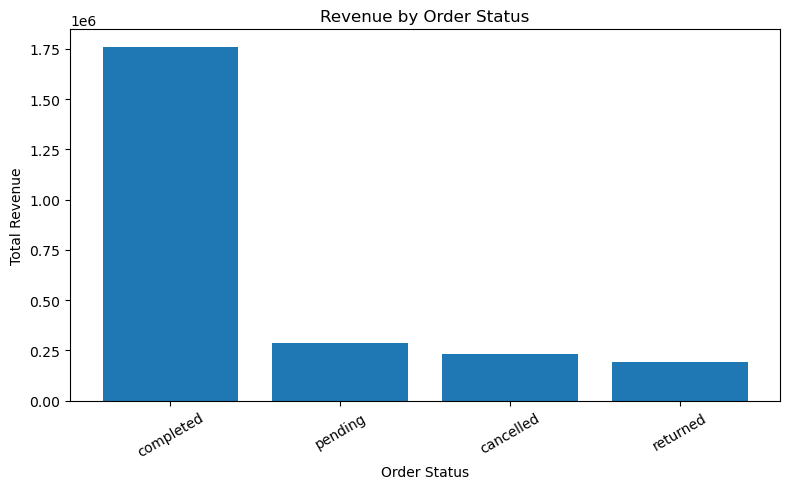

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(revenue_by_status["order_status"], revenue_by_status["total_revenue"])
plt.title("Revenue by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Confirming all business output files exists

In [45]:
expected_business_files = [
    "data/phase1_revenue_by_status.csv",
    "data/phase1_revenue_by_category.csv",
    "data/phase1_daily_revenue.csv",
    "docs/screenshots/11_revenue_by_order_status_chart.png"
]

for file in expected_business_files:
    path = Path(file)
    print(f"{file}: {path.exists()}")

data/phase1_revenue_by_status.csv: True
data/phase1_revenue_by_category.csv: True
data/phase1_daily_revenue.csv: True
docs/screenshots/11_revenue_by_order_status_chart.png: True


## Final Phase 1 Summary

In [46]:
phase1_summary = {
    "raw_customers_rows": len(customers),
    "raw_products_rows": len(products),
    "raw_orders_rows": len(orders),
    "validation_rules_passed": passed_count,
    "validation_rules_failed": failed_count,
    "business_outputs_created": 3,
    "phase_status": "Phase 1 completed successfully"
}

phase1_summary

{'raw_customers_rows': 500,
 'raw_products_rows': 100,
 'raw_orders_rows': 3000,
 'validation_rules_passed': 17,
 'validation_rules_failed': 0,
 'business_outputs_created': 3,
 'phase_status': 'Phase 1 completed successfully'}

## saving phase 1 summary

In [47]:
phase1_summary_df = pd.DataFrame([phase1_summary])

phase1_summary_df.to_csv("data/phase1_completion_summary.csv", index=False)

display(phase1_summary_df)

,raw_customers_rows,raw_products_rows,raw_orders_rows,validation_rules_passed,validation_rules_failed,business_outputs_created,phase_status
0,500,100,3000,17,0,3,Phase 1 completed successfully


## Final check

In [49]:
expected_files = [
    "data/raw/customers.csv",
    "data/raw/products.csv",
    "data/raw/orders.csv",
    "data/phase1_validation_summary.csv",
    "data/phase1_revenue_by_status.csv",
    "data/phase1_revenue_by_category.csv",
    "data/phase1_daily_revenue.csv",
    "data/phase1_completion_summary.csv",
    "docs/screenshots/11_revenue_by_order_status_chart.png"
]

for file in expected_files:
    path = Path(file)
    print(f"{file}: {path.exists()}")

data/raw/customers.csv: True
data/raw/products.csv: True
data/raw/orders.csv: True
data/phase1_validation_summary.csv: True
data/phase1_revenue_by_status.csv: True
data/phase1_revenue_by_category.csv: True
data/phase1_daily_revenue.csv: True
data/phase1_completion_summary.csv: True
docs/screenshots/11_revenue_by_order_status_chart.png: True
